# Inference

In [1]:
try:
    import mat73
except ImportError:
    pass

from pathlib import Path
from typing import Sequence

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

In [2]:
path = "../../../"
path = Path(path).expanduser()
import sys

sys.path.insert(0, str(path))

In [3]:
import decode
import decode.neuralfitter.inference.functional as infer_func
print(decode.__file__)
log = decode.generic.logging.get_logger(__name__)

%config InlineBackend.figure_format='retina'

/data1/shah/miniconda3/envs/decode_uipsf/lib/python3.10/site-packages/torchmetrics/utilities/imports.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


/home/shahao/projects/DECODE-Plex/notebook/biplane/simulation/../../../decode/__init__.py


In [ ]:
# some paths and hardware settings
path_trafo = "../../../calibration/Fig1c_2c-Pos0_240621_NC_BeadCal_BifocalPlane_Z_1_MMStack_Default.ome_trafo.mat"

path_out = "../../../data/Fig1c_S5-density/Fig1c-biplane/n_frames-1000_n_steps-16_seed-42"
path_out = Path(path_out).expanduser()

trafo_size_ref = 512
trafo_mirr_dim = 0

device = ["cuda:0"]

path_trafo = Path(path_trafo).expanduser()

In [ ]:
path_scen_base = "../../../data/Fig1c_S5-density/Fig1c-biplane/n_frames-1000_n_steps-16_seed-42"
path_scen_base = Path(path_scen_base)

path_scen = path_scen_base / "scenarios.pq"
scen = pd.read_parquet(path_scen)

path_frames = path_scen_base / "frames.pt"
frames = torch.load(path_frames)

img_shape = frames[0][0].shape[-2:]

scen_model = pd.DataFrame(index=scen.index)

pm = {
    # "high": "~/decode_storage/dev/lucas/training/dual_sim/2024-02-09_15-55-27-849250",
    "medium": "../../../outputs/Fig1c-biplane-density",
    # "low": "~/decode_storage/dev/lucas/training/dual_sim/2024-02-09_17-16-13-546570",
}
pm = {k: Path(v).expanduser() for k, v in pm.items()}

# map models to scenarios
scen_model["path_model"] = None
for snr in pm:
    scen_model.loc[snr, "path_model"] = pm[snr]

scen_model

path_model
snr    index                                        
medium 0      ../../../outputs/Fig1c-biplane-density
       1      ../../../outputs/Fig1c-biplane-density
       2      ../../../outputs/Fig1c-biplane-density
       3      ../../../outputs/Fig1c-biplane-density
       4      ../../../outputs/Fig1c-biplane-density
       5      ../../../outputs/Fig1c-biplane-density
       6      ../../../outputs/Fig1c-biplane-density
       7      ../../../outputs/Fig1c-biplane-density
       8      ../../../outputs/Fig1c-biplane-density
       9      ../../../outputs/Fig1c-biplane-density
       10     ../../../outputs/Fig1c-biplane-density
       11     ../../../outputs/Fig1c-biplane-density
       12     ../../../outputs/Fig1c-biplane-density
       13     ../../../outputs/Fig1c-biplane-density
       14     ../../../outputs/Fig1c-biplane-density
       15     ../../../outputs/Fig1c-biplane-density

In [6]:
# construct trafo - DO NOT EDIT - COPY FROM SAMPLE
# offset = [-14, 0, 0] # found out by cli tool in decode
offset = [47., -13., 0.] 
trafo = decode.io.trafo.load_xyz_trafo(
    path_trafo,
    scale=1 / 1000.0,
    switch_xy=True,
    shift=(1.0, 1.0, 0.0),
    reference="trafo_inv_raw",
    device=device[0],
)
t_mirr = decode.simulation.trafo.pos.trafo.XYZMirrorAt.from_frame_flip(
    trafo_size_ref,
    trafo_mirr_dim,
    device=device[0],
)
t_mirr = decode.simulation.trafo.pos.trafo.XYZChanneledTransformation(
    t_mirr,
    ch=1,
)
trafo.append(t_mirr)
trafo_shift = decode.simulation.trafo.pos.trafo.XYZShiftTransformation(
    offset, device=device[0]
)
trafo_shift = decode.simulation.trafo.pos.trafo.XYZChanneledTransformation(trafo_shift, 1)

# final trafo
trafo.append(trafo_shift)
trafo = trafo.to("cpu")
# trafo = decode.simulation.trafo.pos.trafo.XYZTransformationNoOp(n_channels=2)
trafo

2026-04-27 18:32:28 [info     ] Running experimental function `load_xyz_trafo` tested=True


XYZCompositTransformation([
    XYZShiftTransformation(tensor([1., 1., 0.]), cpu),
    XYZScaleTransformation(0.0010000000474974513, global),
    XYZTransformationGeneric(<function _coord_permute_smap at 0x7bffcb6fb5b0>, None, cpu, True),
    XYZTransformationMatrix(tensor([[[ 1.0000,  0.0000,  0.0000],
         [ 0.0000,  1.0000,  0.0000],
         [ 0.0000,  0.0000,  1.0000]],

        [[ 1.0016, -0.0362,  0.0020],
         [-0.0362, -1.0010,  0.0012],
         [ 0.0174,  0.5653,  1.0000]]])),
    XYZTransformationGeneric(<function _coord_permute_smap at 0x7bffcb6fb5b0>, None, cpu, True),
    XYZScaleTransformation(1000.0, global),
    XYZShiftTransformation(tensor([-1., -1., -0.]), cpu),
    XYZChanneledTransformation(XYZMirrorAt(axis=0, at=511, device=cpu), 1),
    XYZChanneledTransformation(XYZShiftTransformation(tensor([ 47., -13.,   0.]), cpu), 1)
])

# Infer

In [7]:
import decode.neuralfitter.inference.functional as infer_func

def patch_load(path_cfg):
    cfg = decode.io.param.load(path_cfg)

    # patches
    cfg["Paths"]["trafo"] = path_trafo
    cfg = decode.io.param.patch_img_size(cfg, img_shape, scenario=["Simulation", "Test"])

    for i in range(2):
        cfg["Camera"][i]["specs"] |= {"flip": {"gain": None, "channel": None}}

    # scoped fixes
    for s in ["Simulation", "Test"]:
        # integer offset
        # cfg[s]["Transformation"]["Pos"]["glob"]["offset"] = {"x": [0, -14], "y": [0, 0], "z": [0, 0]}
        cfg[s]["Transformation"]["Pos"]["glob"]["offset"] = {"x": [0, 0], "y": [0, 0], "z": [0, 0]}

    return cfg

In [8]:
scen_model["em"] = None

for i, r in scen_model.iterrows():
    if r["path_model"] is None:
        continue

    path_model = Path(r["path_model"])
    path_ckpt = sorted(path_model.glob("*.ckpt"))[0]
    path_cfg = path_model / "param_run.yaml"

    log.info(f"Loading model, config for scenario", index=i, path_model=path_model, path_ckpt=path_ckpt, path_cfg=path_cfg)

    cfg = patch_load(path_cfg)
    cfg["Hardware"]["device"]["training"] = device[0]

    f = frames[i[-1]]

    em_out, logger = infer_func.infer(
        f,
        frame_crop=(256, 256),
        cfg=cfg,
        model=path_ckpt,
        mode="multi",
        trafo=trafo,
        mode_camera="cameras",
        logger="debug",
        device = device,
    )

    scen_model.at[i, "em"] = em_out

scen_model

2026-04-27 18:32:37 [info     ] Loading model, config for scenario index=('medium', 0) path_cfg=PosixPath('../../../outputs/Fig1c-biplane-density/param_run.yaml') path_ckpt=PosixPath('../../../outputs/Fig1c-biplane-density/epoch=999-step=625000.ckpt') path_model=PosixPath('../../../outputs/Fig1c-biplane-density')
2026-04-27 18:32:37 [info     ] Running experimental function `infer` tested=False
2026-04-27 18:32:37 [info     ] Running experimental function `load_model` tested=False
2026-04-27 18:32:38 [info     ] No flipping of frames due to camera.
2026-04-27 18:32:38 [info     ] Setting up frame pre-processing in multi-camera mode.
2026-04-27 18:32:38 [info     ] Offsets as specified in config. offset=[(0, 0), (0, 0)]
2026-04-27 18:32:52 [info     ] Inferred batch size as         batch_size=40 num_gpus=1 per_gpu=40


100%|██████████| 25/25 [00:30<00:00,  1.24s/it]


2026-04-27 18:33:23 [info     ] Loading model, config for scenario index=('medium', 1) path_cfg=PosixPath('../../../outputs/Fig1c-biplane-density/param_run.yaml') path_ckpt=PosixPath('../../../outputs/Fig1c-biplane-density/epoch=999-step=625000.ckpt') path_model=PosixPath('../../../outputs/Fig1c-biplane-density')
2026-04-27 18:33:24 [info     ] Running experimental function `infer` tested=False
2026-04-27 18:33:24 [info     ] Running experimental function `load_model` tested=False
2026-04-27 18:33:24 [info     ] No flipping of frames due to camera.
2026-04-27 18:33:24 [info     ] Setting up frame pre-processing in multi-camera mode.
2026-04-27 18:33:24 [info     ] Offsets as specified in config. offset=[(0, 0), (0, 0)]
2026-04-27 18:33:38 [info     ] Inferred batch size as         batch_size=38 num_gpus=1 per_gpu=38


100%|██████████| 27/27 [00:30<00:00,  1.14s/it]


2026-04-27 18:34:08 [info     ] Loading model, config for scenario index=('medium', 2) path_cfg=PosixPath('../../../outputs/Fig1c-biplane-density/param_run.yaml') path_ckpt=PosixPath('../../../outputs/Fig1c-biplane-density/epoch=999-step=625000.ckpt') path_model=PosixPath('../../../outputs/Fig1c-biplane-density')
2026-04-27 18:34:09 [info     ] Running experimental function `infer` tested=False
2026-04-27 18:34:09 [info     ] Running experimental function `load_model` tested=False
2026-04-27 18:34:09 [info     ] No flipping of frames due to camera.
2026-04-27 18:34:09 [info     ] Setting up frame pre-processing in multi-camera mode.
2026-04-27 18:34:09 [info     ] Offsets as specified in config. offset=[(0, 0), (0, 0)]
2026-04-27 18:34:21 [info     ] Inferred batch size as         batch_size=37 num_gpus=1 per_gpu=37


...

2026-04-27 18:41:52 [warning  ] Frame input above typical value range (-1, 5) limits=(5.0, inf) mass=0.0017560323467478156
2026-04-27 18:41:52 [warning  ] Frame input above typical value range (-1, 5) limits=(5.0, inf) mass=0.0017666287021711469
2026-04-27 18:41:52 [warning  ] Frame input above typical value range (-1, 5) limits=(5.0, inf) mass=0.0017606946639716625
2026-04-27 18:41:52 [warning  ] Frame input above typical value range (-1, 5) limits=(5.0, inf) mass=0.0003403557639103383
2026-04-27 18:41:52 [warning  ] Frame input above typical value range (-1, 5) limits=(5.0, inf) mass=0.00035519071388989687
2026-04-27 18:41:52 [warning  ] Frame input above typical value range (-1, 5) limits=(5.0, inf) mass=0.00035858154296875


 67%|██████▋   | 2/3 [00:03<00:01,  1.75s/it]

2026-04-27 18:41:53 [warning  ] Frame input above typical value range (-1, 5) limits=(5.0, inf) mass=0.0017885480774566531
2026-04-27 18:41:53 [warning  ] Frame input above typical value range (-1, 5) limits=(5.0, inf) mass=0.0018136160215362906
2026-04-27 18:41:53 [warning  ] Frame input above typical value range (-1, 5) limits=(5.0, inf) mass=0.0018583025084808469
2026-04-27 18:41:53 [warning  ] Frame input above typical value range (-1, 5) limits=(5.0, inf) mass=0.00039454869693145156
2026-04-27 18:41:53 [warning  ] Frame input above typical value range (-1, 5) limits=(5.0, inf) mass=0.00036839075619354844
2026-04-27 18:41:53 [warning  ] Frame input above typical value range (-1, 5) limits=(5.0, inf) mass=0.00035858154296875


100%|██████████| 3/3 [00:04<00:00,  1.49s/it]


path_model  \
snr    index                                           
medium 0      ../../../outputs/Fig1c-biplane-density   
       1      ../../../outputs/Fig1c-biplane-density   
       2      ../../../outputs/Fig1c-biplane-density   
       3      ../../../outputs/Fig1c-biplane-density   
       4      ../../../outputs/Fig1c-biplane-density   
       5      ../../../outputs/Fig1c-biplane-density   
       6      ../../../outputs/Fig1c-biplane-density   
       7      ../../../outputs/Fig1c-biplane-density   
       8      ../../../outputs/Fig1c-biplane-density   
       9      ../../../outputs/Fig1c-biplane-density   
       10     ../../../outputs/Fig1c-biplane-density   
       11     ../../../outputs/Fig1c-biplane-density   
       12     ../../../outputs/Fig1c-biplane-density   
       13     ../../../outputs/Fig1c-biplane-density   
       14     ../../../outputs/Fig1c-biplane-density   
       15     ../../../outputs/Fig1c-biplane-density   

                                                             em  
snr    index                                                     
medium 0      EmitterSet
::num emitters: 12732
::xy unit: px...  
       1      EmitterSet
::num emitters: 16997
::xy unit: px...  
       2      EmitterSet
::num emitters: 22688
::xy unit: px...  
       3      EmitterSet
::num emitters: 30474
::xy unit: px...  
       4      EmitterSet
::num emitters: 41632
::xy unit: px...  
       5      EmitterSet
::num emitters: 55210
::xy unit: px...  
       6      EmitterSet
::num emitters: 75461
::xy unit: px...  
       7      EmitterSet
::num emitters: 101235
::xy unit: p...  
       8      EmitterSet
::num emitters: 99906
::xy unit: px...  
       9      EmitterSet
::num emitters: 100059
::xy unit: p...  
       10     EmitterSet
::num emitters: 100305
::xy unit: p...  
       11     EmitterSet
::num emitters: 98214
::xy unit: px...  
       12     EmitterSet
::num emitters: 96869
::xy unit: px...  
       13     EmitterSet
::num emitters: 94783
::xy unit: px...  
       14     EmitterSet
::num emitters: 90674
::xy unit: px...  
       15     EmitterSet
::num emitters: 86260
::xy unit: px...

In [9]:
path_em = path_scen_base / "decode_fit.pt"
torch.save(scen_model.droplevel(0)["em"].to_dict(), path_em)

# DEBUG

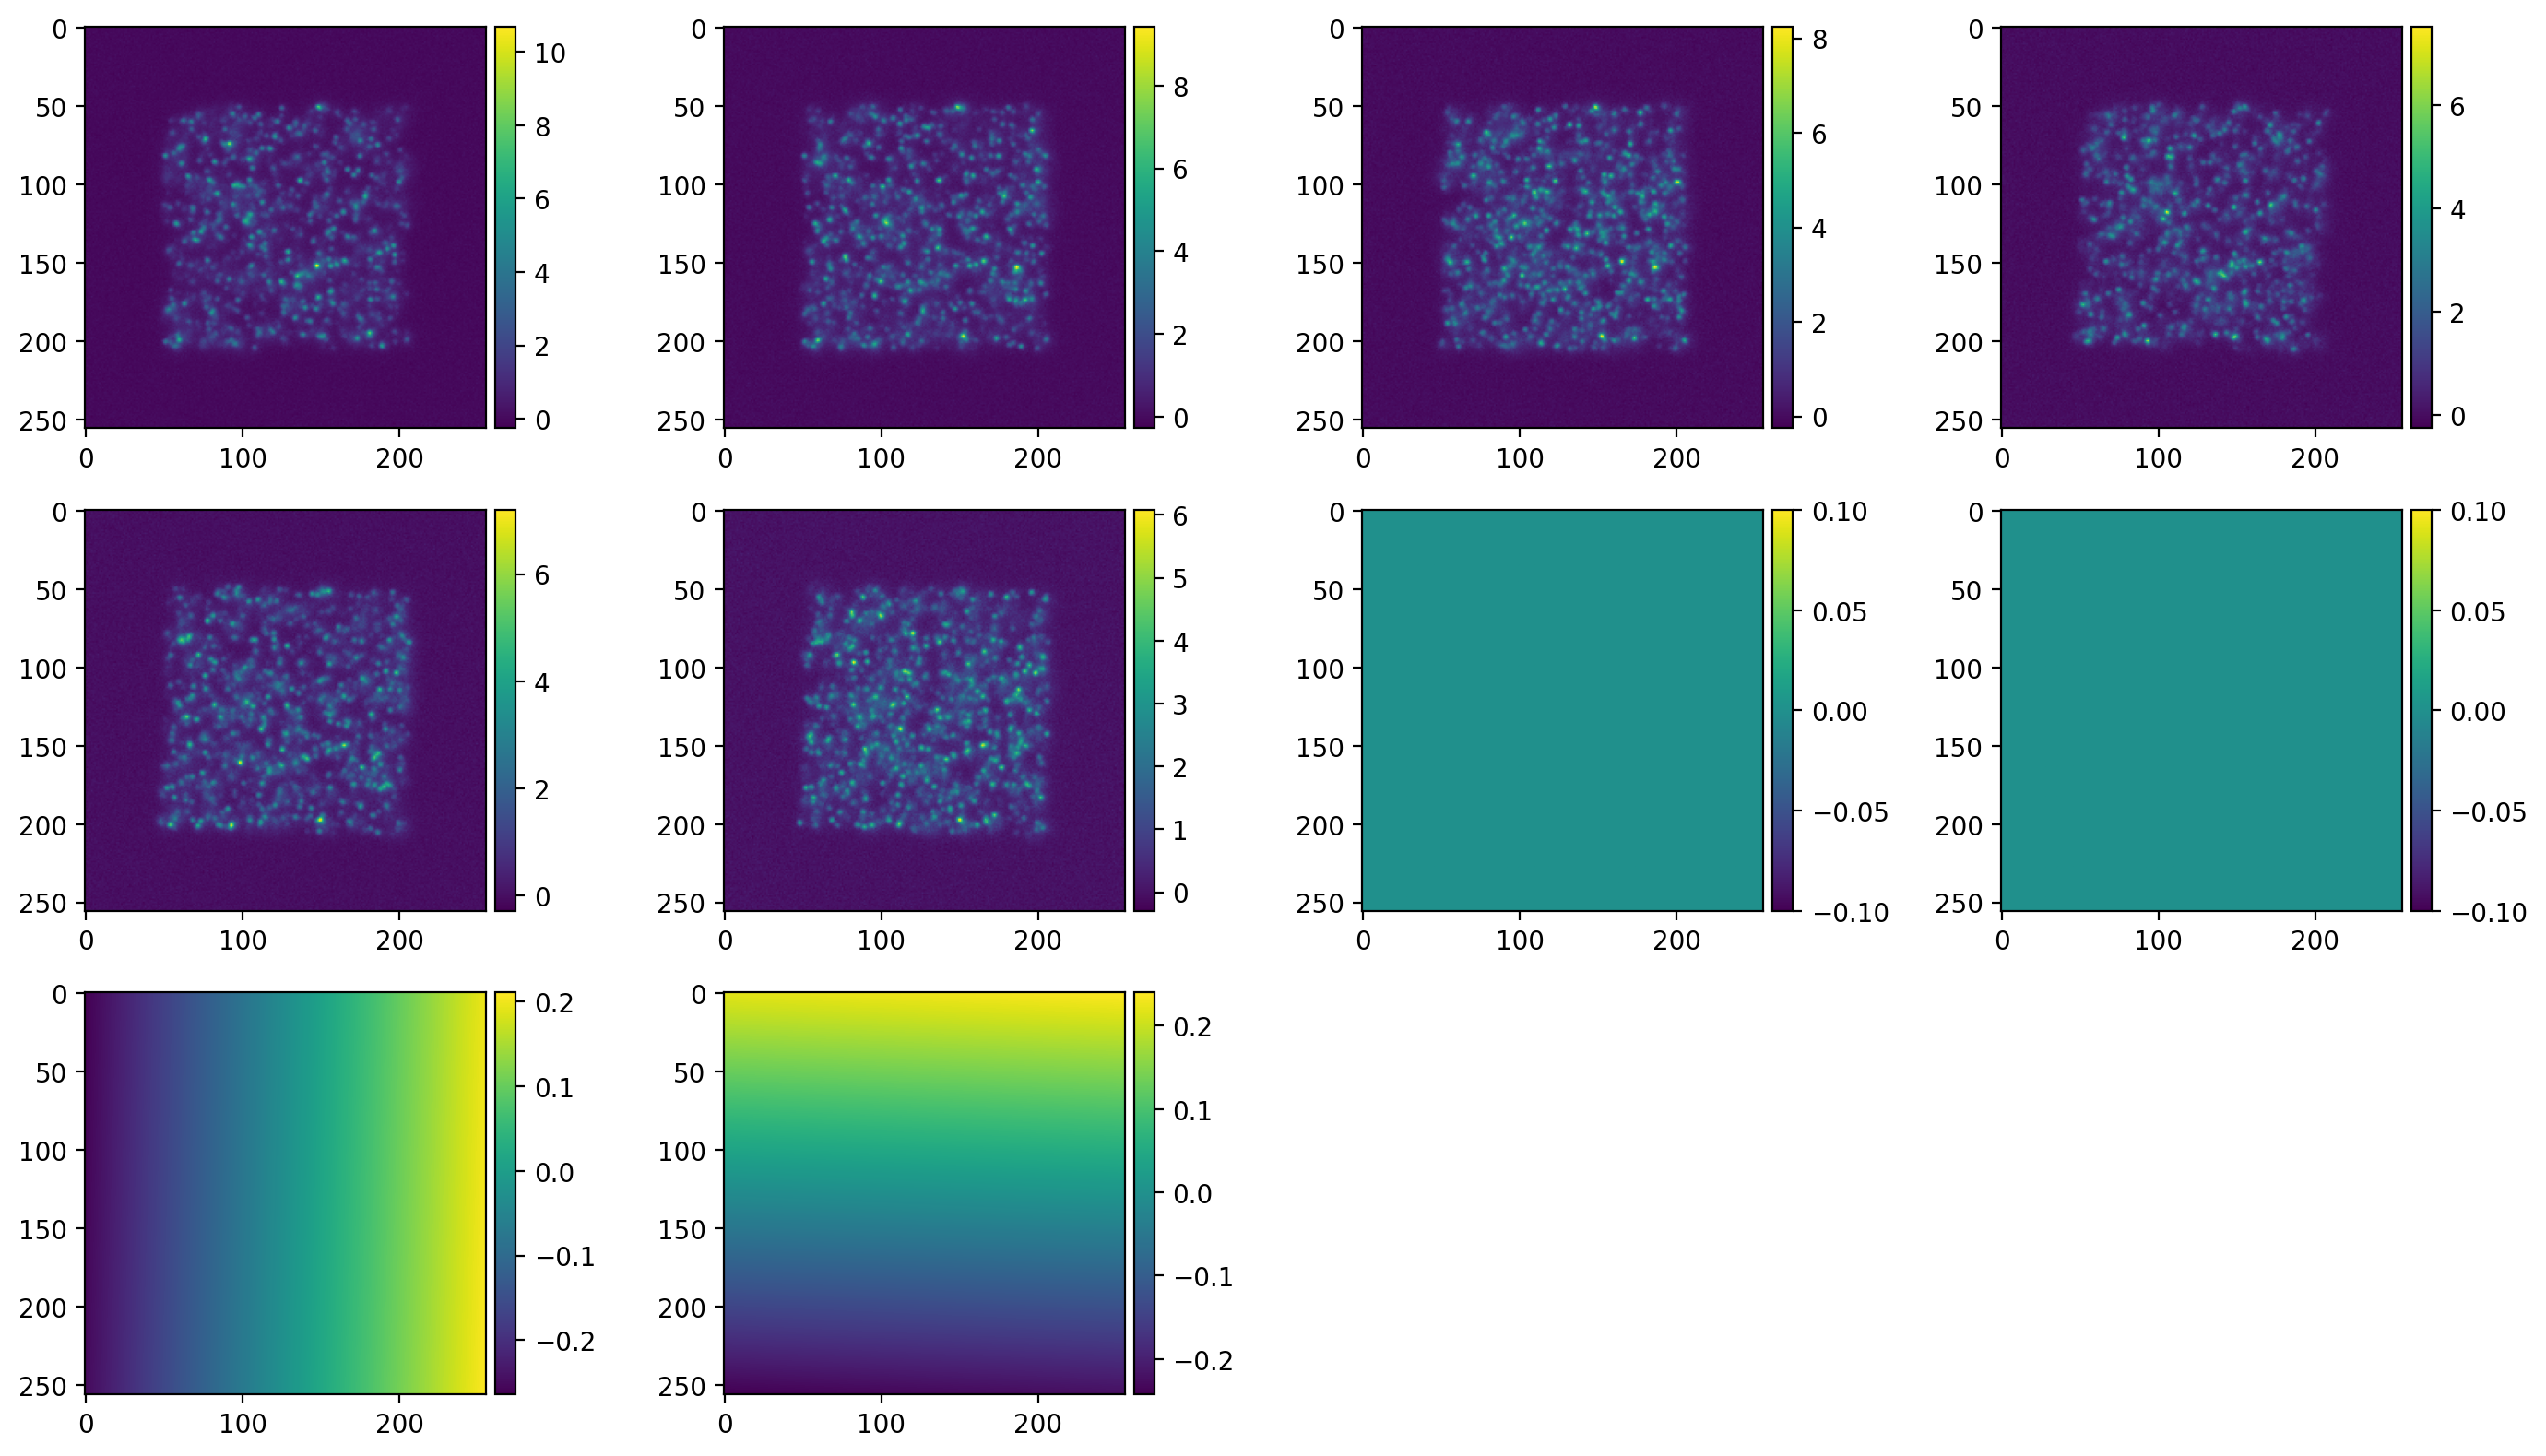

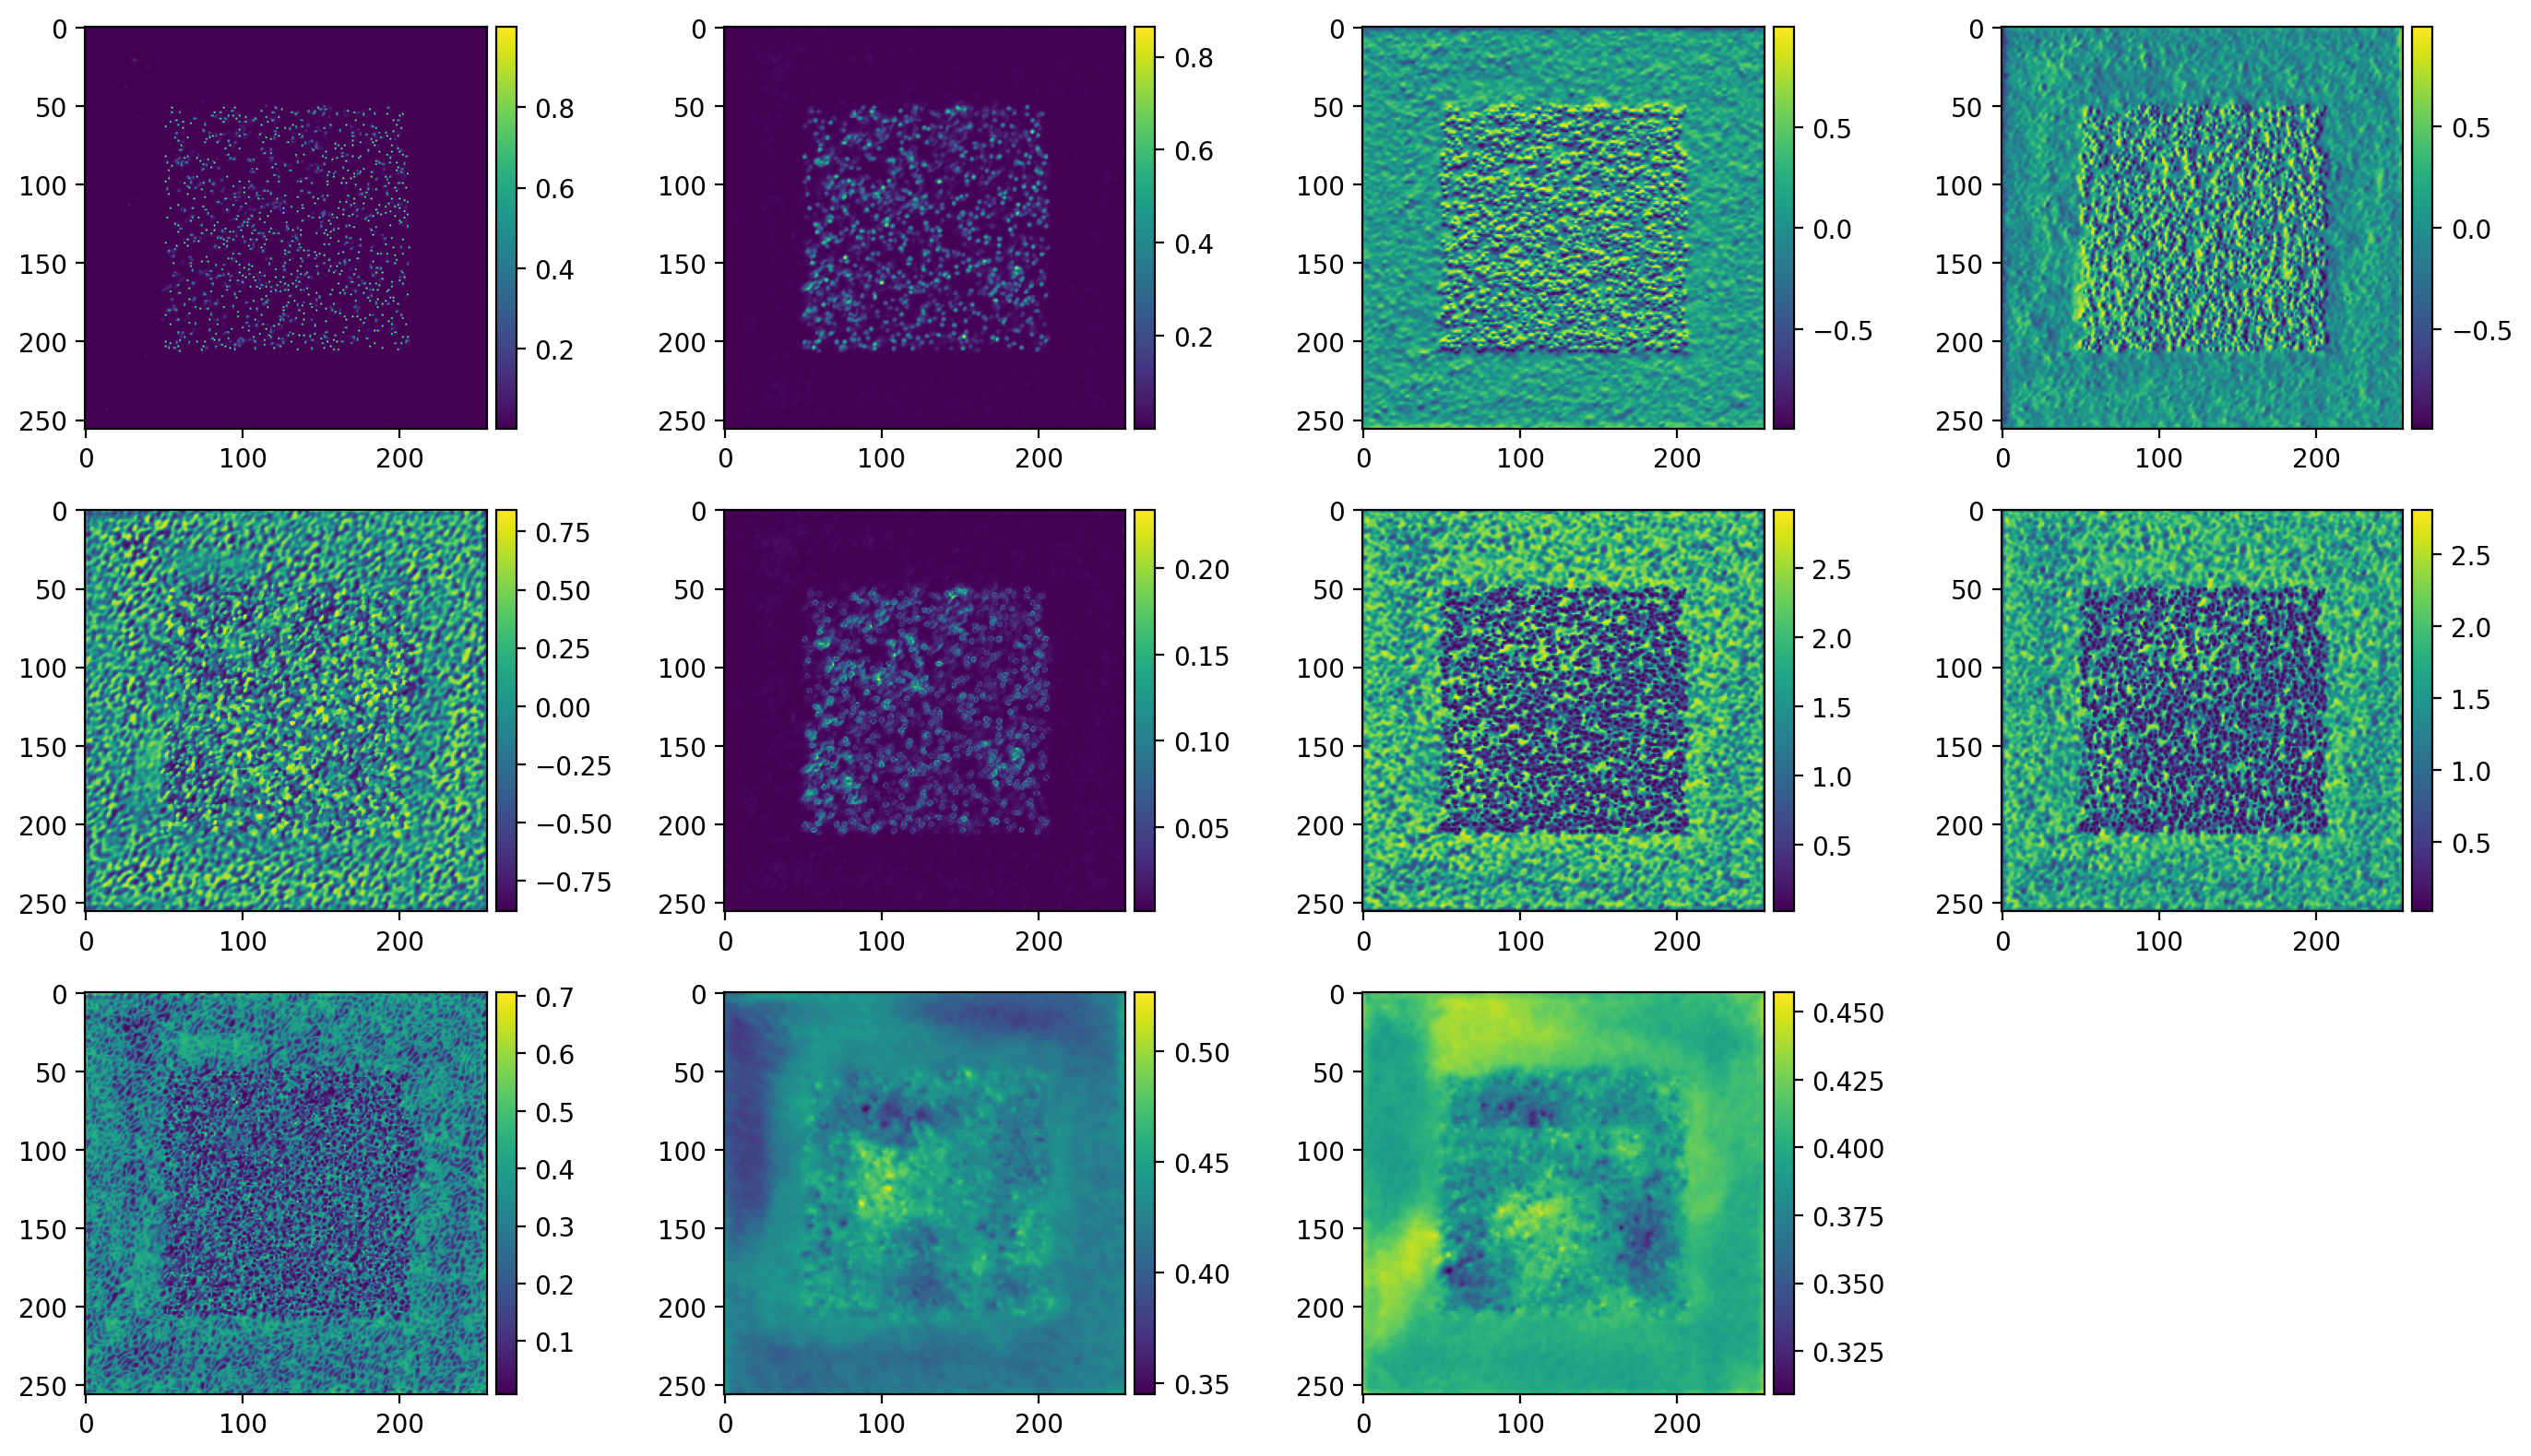

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# plot all inputs and raw outputs
f_ix = 2

f, axs = plt.subplots(ncols=4, nrows=3, figsize=(14, 8))
for i, ax in enumerate(axs.flatten()):
    x = logger.model_in[0][f_ix]
    if i >= x.shape[0]:
        ax.axis("off")
        continue
    im = ax.imshow(x[i])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax)

plt.tight_layout()
plt.show()

f, axs = plt.subplots(ncols=4, nrows=3, figsize=(14, 8))
for i, ax in enumerate(axs.flatten()):
    x = logger.model_out[0][f_ix].cpu().numpy()
    if i >= x.shape[0]:
        ax.axis("off")
        continue

    im = ax.imshow(x[i])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax)
plt.tight_layout()
plt.show()